In [1]:
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import preliz as pz

In [2]:
plt.rc('figure', dpi=300)
np.random.seed(123)

In [3]:
cs_data = pd.read_csv('data/chemical_shifts_theo_exp.csv')
cs_data

,ID,aa,theo,exp,cat
0,1BM8,ILE,61.18,58.27,Non-Polar
1,1BM8,TYR,56.95,56.18,Polar
2,1BM8,SER,56.35,56.84,Polar
3,1BM8,ALA,51.96,51.01,Special
4,1BM8,ARG,56.54,54.64,Charged
...,...,...,...,...,...
1771,1KS9,LYS,55.79,57.51,Charged
1772,1KS9,ARG,58.91,59.02,Charged
1773,1KS9,LYS,59.49,58.92,Charged
1774,1KS9,GLU,59.48,58.36,Charged


In [4]:
diff = cs_data['theo'] - cs_data['exp']
diff

0       2.91
1       0.77
2      -0.49
3       0.95
4       1.90
        ... 
1771   -1.72
1772   -0.11
1773    0.57
1774    1.12
1775   -2.48
Length: 1776, dtype: float64

In [5]:
cat_enc = pd.Categorical(cs_data['aa'])
cat_enc

['ILE', 'TYR', 'SER', 'ALA', 'ARG', ..., 'LYS', 'ARG', 'LYS', 'GLU', 'SER']
Length: 1776
Categories (19, object): ['ALA', 'ARG', 'ASN', 'ASP', ..., 'THR', 'TRP', 'TYR', 'VAL']

In [6]:
idx = cat_enc.codes
idx

array([ 8, 17, 14, ..., 10,  5, 14], dtype=int8)

In [7]:
coords = {'aa': cat_enc.categories}
coords

{'aa': Index(['ALA', 'ARG', 'ASN', 'ASP', 'GLN', 'GLU', 'GLY', 'HIS', 'ILE', 'LEU',
        'LYS', 'MET', 'PHE', 'PRO', 'SER', 'THR', 'TRP', 'TYR', 'VAL'],
       dtype='object')}

In [8]:
with pm.Model(coords=coords) as cs_nh:
    # 아미노산별 평균을 위한 정규분포 정의 (각 카테고리에 대해서 μ를 생성)
    μ = pm.Normal('μ', mu=0, sigma=10, dims="aa") 
    # 아미노산별 표준편차를 위한 Half-Normal 분포 정의 (각 카테고리에 대해서 σ를 생성)
    σ = pm.HalfNormal('σ', sigma=10, dims="aa") 

    # 관측된 화학적 변위 차이를 모델링 (각 관측값에 대응하는 μ와 σ를 이용)
    y = pm.Normal('y', mu=μ[idx], sigma=σ[idx], observed=diff) 

    # MCMC 샘플링을 통한 추정 결과 생성
    idata_cs_nh = pm.sample(random_seed=4591)

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [μ, σ]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 6 seconds.


In [9]:
idata_cs_nh

Inference data with groups:
	> posterior
	> sample_stats
	> observed_data

In [10]:
posterior = idata_cs_nh.posterior

In [11]:
display(posterior.μ[0,:,0])
display(posterior.σ[0,:,0])
posterior.aa[0]

<xarray.DataArray 'μ' (draw: 1000)>
array([0.39497485, 0.3798061 , 0.38812472, 0.33583616, 0.4946394 ,
       0.12870033, 0.59388009, 0.10559408, 0.52332613, 0.19096122,
       0.54270393, 0.22756642, 0.44279034, 0.34846917, 0.53952735,
       0.17173108, 0.40440424, 0.31674484, 0.38599825, 0.22248523,
       0.54629714, 0.31671344, 0.41409659, 0.35282968, 0.33168202,
       0.44507599, 0.34465734, 0.43241942, 0.12941919, 0.55023503,
       0.13341297, 0.49269221, 0.32091968, 0.39846462, 0.3042693 ,
       0.3663989 , 0.31667815, 0.29297349, 0.46670206, 0.2604195 ,
       0.46266668, 0.19523774, 0.54919134, 0.34551905, 0.32155698,
       0.44547181, 0.33166922, 0.41275562, 0.36893623, 0.30367228,
       0.39531973, 0.31229864, 0.53956098, 0.28528075, 0.39557231,
       0.34520392, 0.43776012, 0.26550077, 0.45899456, 0.21404507,
       0.46625913, 0.26226103, 0.45395692, 0.26251603, 0.28601649,
       0.15048831, 0.24742222, 0.43561298, 0.49058245, 0.42208242,
       0.43532474, 0.37608863, 0.39529837, 0.45489765, 0.26509603,
       0.43186045, 0.23547873, 0.40137991, 0.47685757, 0.31910496,
       0.30586315, 0.35411203, 0.46672313, 0.37092346, 0.38756361,
       0.16549619, 0.32923782, 0.41958228, 0.42371372, 0.29965905,
       0.46047541, 0.2819625 , 0.35938801, 0.31250243, 0.40646661,
       0.2923368 , 0.36411439, 0.43673873, 0.41618331, 0.27200868,
...
       0.22379065, 0.40338995, 0.37433325, 0.35612442, 0.41910044,
       0.3031172 , 0.4182859 , 0.42963198, 0.50326822, 0.36121806,
       0.34520955, 0.3731669 , 0.59222267, 0.37875194, 0.25032713,
       0.447086  , 0.38707655, 0.33185843, 0.39277363, 0.2818911 ,
       0.47910945, 0.3860859 , 0.32285379, 0.34535663, 0.33735057,
       0.20220232, 0.50083491, 0.20095107, 0.28418543, 0.25973781,
       0.40569075, 0.46376515, 0.28141586, 0.38861719, 0.2933045 ,
       0.42876124, 0.30776636, 0.35374752, 0.33000712, 0.3953986 ,
       0.3128732 , 0.41829122, 0.31478451, 0.40223133, 0.41147332,
       0.23623224, 0.48991983, 0.09279593, 0.41914675, 0.31951513,
       0.3644154 , 0.36482209, 0.40339371, 0.38025264, 0.36875041,
       0.34803369, 0.47182875, 0.29961165, 0.41616432, 0.36165786,
       0.3129827 , 0.32083885, 0.37181336, 0.40080929, 0.40565293,
       0.45185548, 0.26601593, 0.47062413, 0.25951538, 0.44853807,
       0.23900329, 0.4259832 , 0.26431395, 0.51423858, 0.24636081,
       0.37828689, 0.36038282, 0.38477252, 0.49323332, 0.21675536,
       0.37328497, 0.16591767, 0.42323201, 0.29343523, 0.43450243,
       0.45551263, 0.27713864, 0.49643532, 0.34294876, 0.33945154,
       0.26358572, 0.44857707, 0.38907046, 0.26588508, 0.49808273,
       0.47735352, 0.0971377 , 0.13693523, 0.4393494 , 0.3119892 ])
Coordinates:
    chain    int64 0
  * draw     (draw) int64 0 1 2 3 4 5 6 7 8 ... 992 993 994 995 996 997 998 999
    aa       <U3 'ALA'

<xarray.DataArray 'σ' (draw: 1000)>
array([1.22574643, 1.33736953, 1.34468825, 1.36207608, 1.17308253,
       1.36994121, 1.26599371, 1.36166884, 1.09950329, 1.36347296,
       1.38216977, 1.32613591, 1.18843023, 1.32731087, 1.46901111,
       1.15297018, 1.12129101, 1.22764269, 1.28722674, 1.24525872,
       1.2914354 , 1.23641908, 1.19951047, 1.24777795, 1.33853292,
       1.24678868, 1.26621568, 1.39988888, 1.26187527, 1.27919357,
       1.40146968, 1.28126556, 1.26925936, 1.19105482, 1.29679439,
       1.21805145, 1.14726409, 1.20120915, 1.32737946, 1.21029163,
       1.30101638, 1.28602569, 1.22333949, 1.28446863, 1.24568723,
       1.42827092, 1.14294575, 1.23692272, 1.34550168, 1.16538077,
       1.23768233, 1.2481387 , 1.29639995, 1.23049737, 1.36349991,
       1.14628975, 1.27620338, 1.18502529, 1.26337397, 1.26281409,
       1.2021122 , 1.28672946, 1.26091983, 1.32323525, 1.33882928,
       1.31631952, 1.34412517, 1.18195664, 1.31434805, 1.18694552,
       1.35959698, 1.22495226, 1.37262221, 1.32621719, 1.2674926 ,
       1.28443894, 1.21049111, 1.15311482, 1.23865954, 1.25116223,
       1.28378833, 1.21454206, 1.20848046, 1.10404238, 1.35873362,
       1.20367422, 1.34535155, 1.37597657, 1.16138216, 1.29809449,
       1.50576648, 1.07165466, 1.08160998, 1.21580734, 1.15144845,
       1.36837926, 1.28157083, 1.30491208, 1.22473617, 1.17378379,
...
       1.29384312, 1.14374827, 1.39297102, 1.14599443, 1.37655497,
       1.21411862, 1.24130528, 1.31315417, 1.29532493, 1.26534383,
       1.25736755, 1.33509154, 1.17114211, 1.37178659, 1.43242931,
       1.25664977, 1.30713721, 1.2981441 , 1.24683481, 1.24349605,
       1.22506792, 1.24700971, 1.27967903, 1.29290752, 1.34371809,
       1.27901441, 1.17048836, 1.36463987, 1.23189081, 1.29850422,
       1.34144348, 1.19662324, 1.33390667, 1.1888763 , 1.31261146,
       1.23150861, 1.27078493, 1.1947177 , 1.30076069, 1.213888  ,
       1.25901684, 1.28601332, 1.25634919, 1.29670865, 1.26079395,
       1.27333155, 1.22310167, 1.28282003, 1.23546239, 1.24527964,
       1.24358294, 1.37358242, 1.30723096, 1.27938069, 1.23479314,
       1.28416889, 1.21519551, 1.33689059, 1.12447546, 1.31087345,
       1.16622634, 1.20282645, 1.42659369, 1.33461054, 1.39268766,
       1.31799473, 1.30431052, 1.12629342, 1.42929415, 1.19671515,
       1.25936579, 1.25971496, 1.3428016 , 1.2101856 , 1.29617815,
       1.22787993, 1.24431572, 1.37870215, 1.2834954 , 1.22909634,
       1.29257133, 1.24411094, 1.34112067, 1.25768369, 1.23082743,
       1.29595453, 1.22901758, 1.28873514, 1.16731064, 1.3705512 ,
       1.32964011, 1.24230941, 1.25095749, 1.1946669 , 1.26743535,
       1.29192841, 1.25896846, 1.30413759, 1.32386113, 1.19668995])
Coordinates:
    chain    int64 0
  * draw     (draw) int64 0 1 2 3 4 5 6 7 8 ... 992 993 994 995 996 997 998 999
    aa       <U3 'ALA'

<xarray.DataArray 'aa' ()>
array('ALA', dtype='<U3')
Coordinates:
    aa       <U3 'ALA'

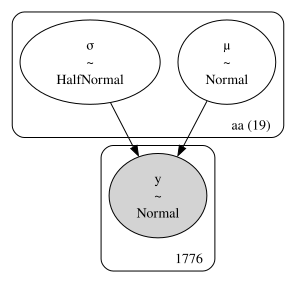

In [12]:
pm.model_to_graphviz(cs_nh)

In [13]:
with pm.Model(coords=coords) as cs_h:
    # hyper_prior
    μ_mu = pm.Normal("μ_mu", mu=0, sigma=10)
    μ_sd = pm.HalfNormal("μ_sd", 10)

    # priors
    μ = pm.Normal("μ", mu=μ_mu, sigma=μ_sd, dims='aa')
    σ = pm.HalfNormal("σ", sigma=10, dims='aa')

    # likelihood
    y = pm.Normal("y", mu=μ[idx], sigma=σ[idx], observed=diff)
    idata_cs_h = pm.sample()

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [μ_mu, μ_sd, μ, σ]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 6 seconds.


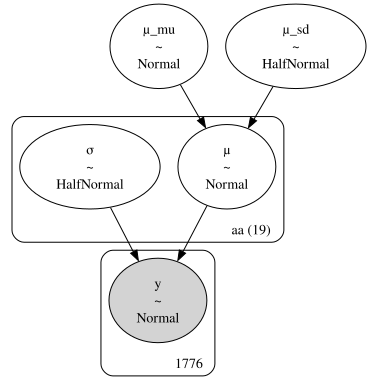

In [14]:
pm.model_to_graphviz(cs_h)

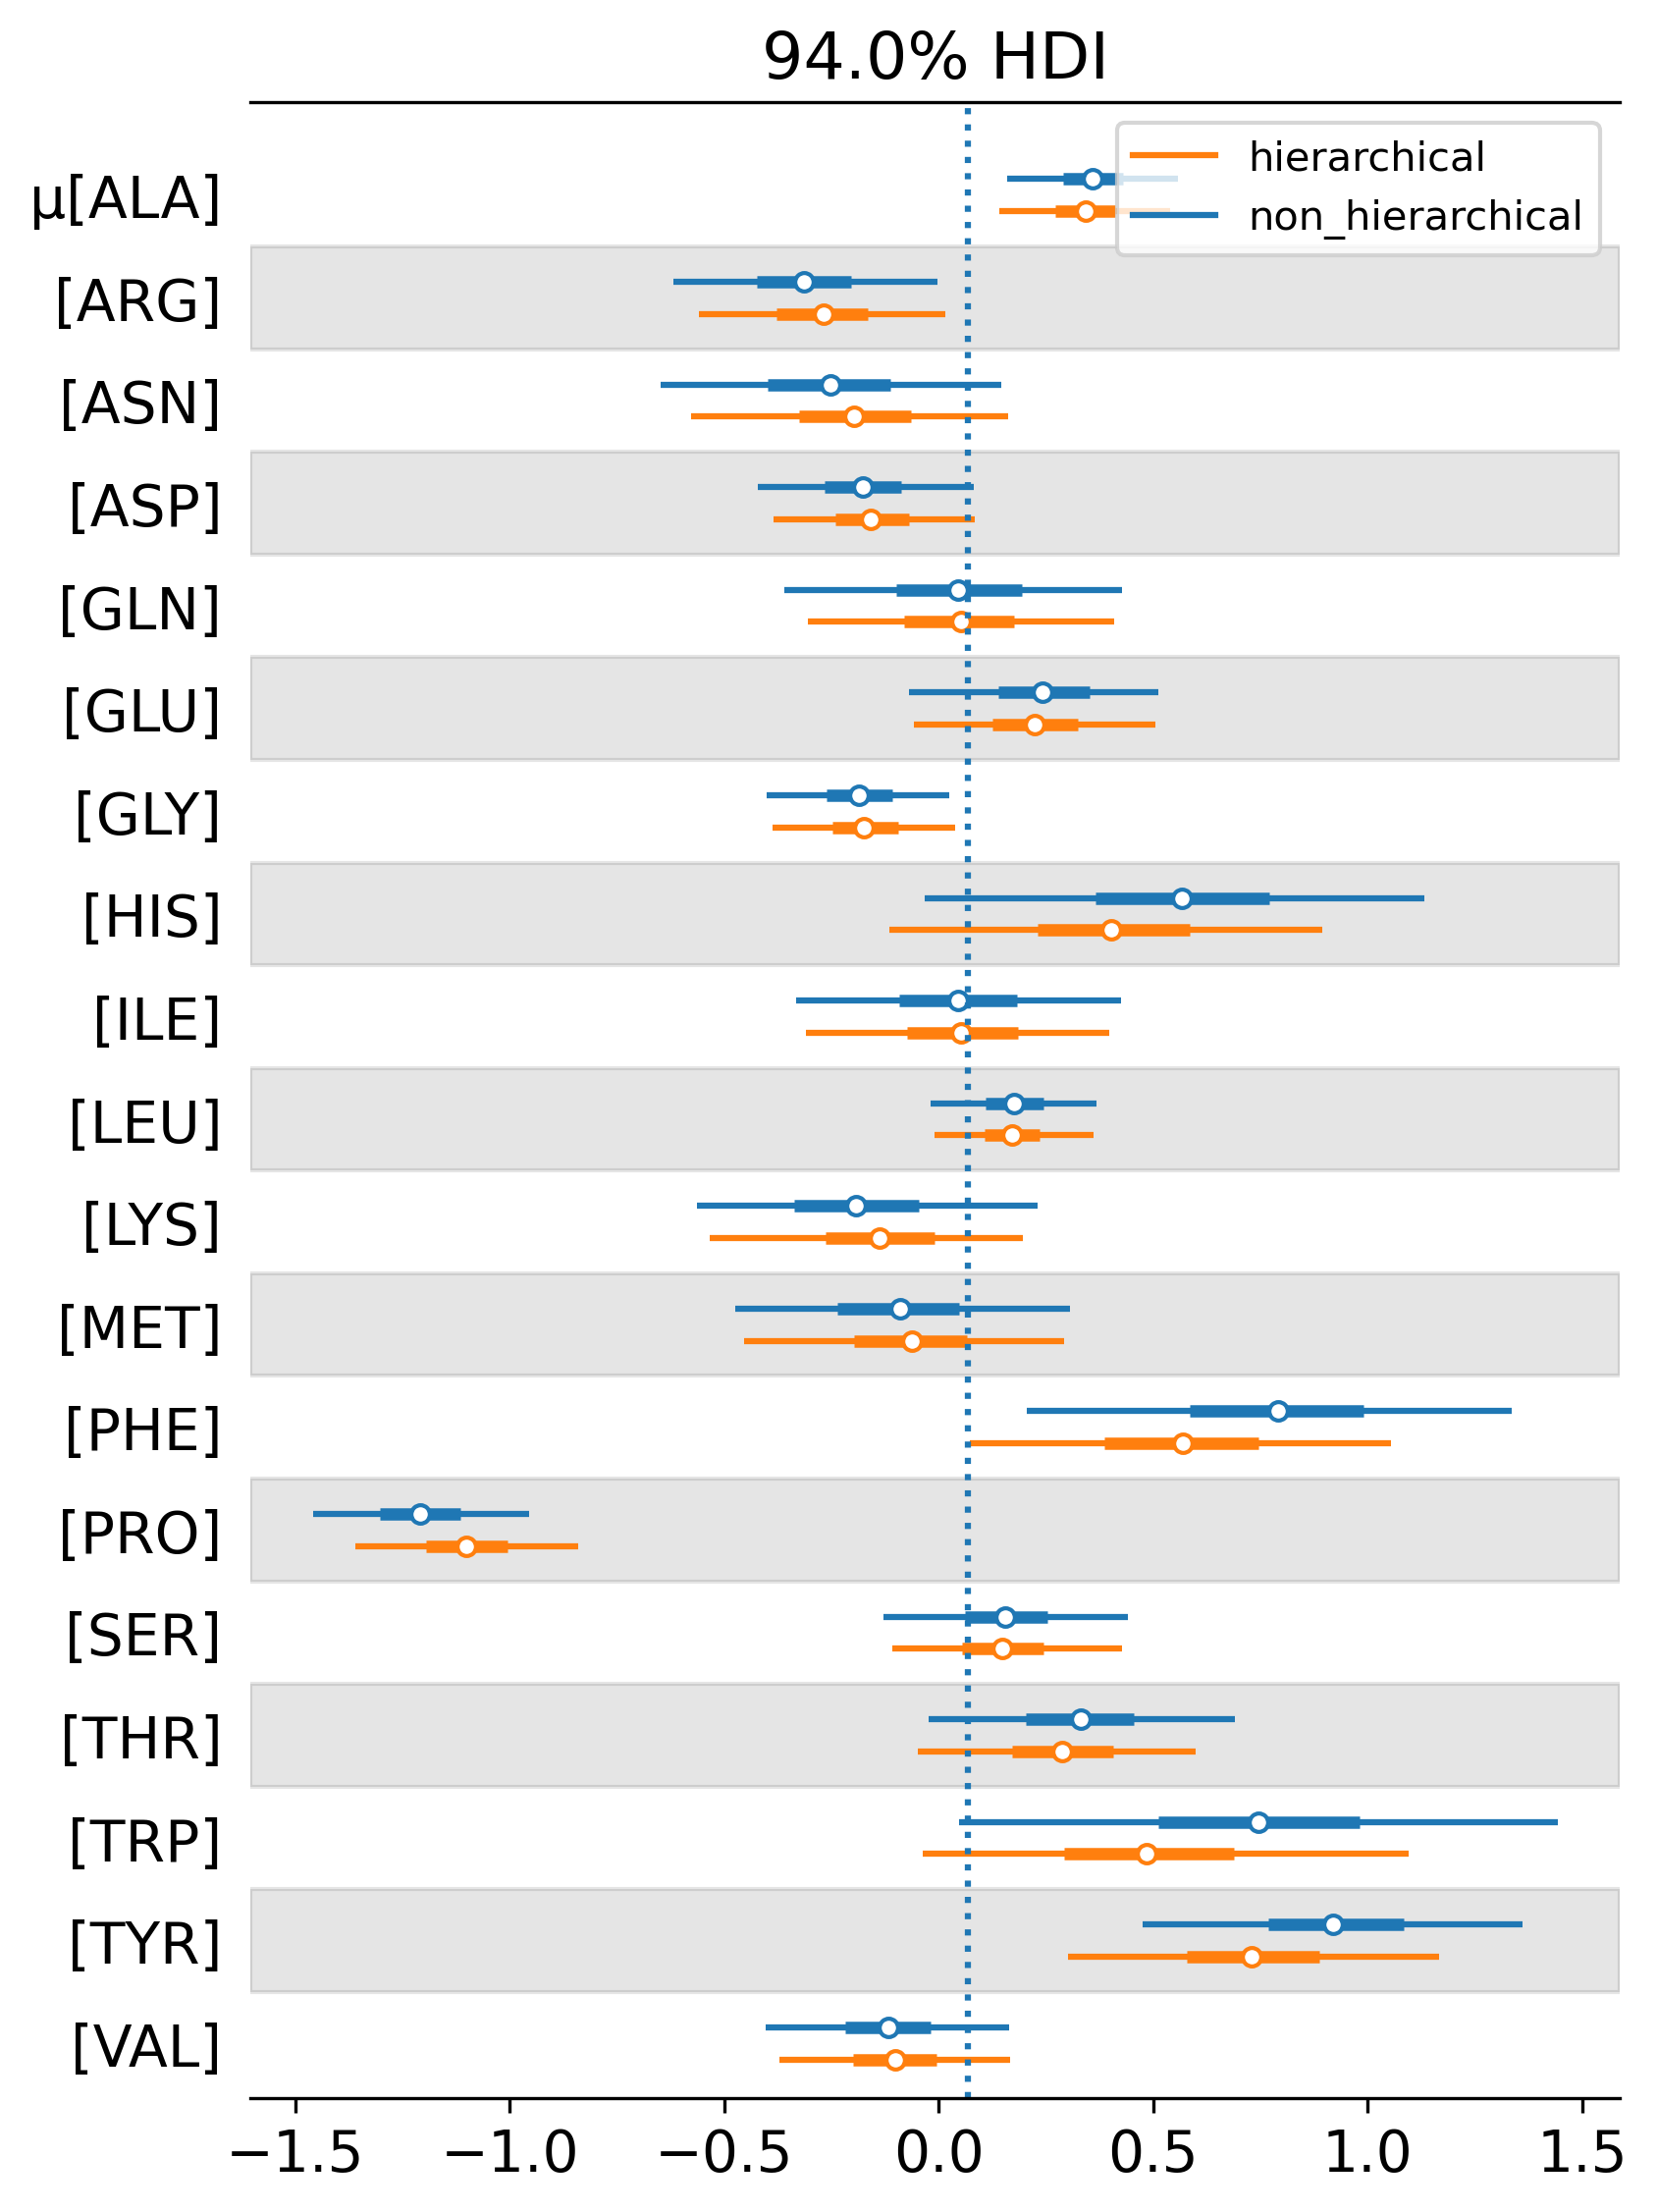

In [15]:
axes = az.plot_forest([idata_cs_nh, idata_cs_h], model_names=['non_hierarchical', 'hierarchical'],
                    var_names='μ', combined=True, r_hat=False, ess=False)
y_lims = axes[0].get_ylim()
axes[0].vlines(idata_cs_h.posterior['μ_mu'].mean(), *y_lims, ls=":")


In [43]:
N_samples = [30, 30, 30]
G_samples = [18, 3, 3]
group_idx = np.repeat(np.arange(len(N_samples)), N_samples)
data = []
for i in range(0, len(N_samples)):
    data.extend(np.repeat([1, 0], [G_samples[i], N_samples[i] - G_samples[i]]))

In [44]:
[G_samples[0], N_samples[0] - G_samples[0]]

[18, 12]

In [45]:
np.repeat([1, 0], [G_samples[i], N_samples[i] - G_samples[i]]).shape

(30,)

In [46]:
data

[1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0]

In [47]:
np.arange(len(N_samples))

array([0, 1, 2])

In [48]:
group_idx.shape

(90,)

In [49]:
with pm.Model() as model_h:
    μ = pm.Beta('μ', 1, 1)
    ν = pm.HalfNormal('ν', 10)

    # prior
    θ = pm.Beta('θ', mu=μ, nu=ν, shape=len(N_samples))

    # likelihood
    y = pm.Bernoulli('y', p=θ[group_idx], observed=data)

    idata_h = pm.sample()

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [μ, ν, θ]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 3 seconds.


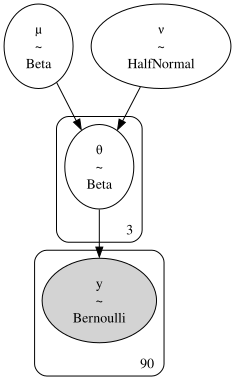

In [50]:
pm.model_to_graphviz(model_h)

In [51]:
test3 = idata_h

In [52]:
az.summary(test1)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
μ,0.583,0.096,0.398,0.758,0.002,0.001,2784.0,2623.0,1.0
ν,12.194,6.177,1.253,23.213,0.111,0.078,2799.0,2415.0,1.0
θ[0],0.597,0.080,0.446,0.744,0.001,0.001,3405.0,2855.0,1.0
θ[1],0.593,0.080,0.440,0.740,0.001,0.001,2869.0,2385.0,1.0
θ[2],0.597,0.078,0.446,0.741,0.001,0.001,3328.0,2449.0,1.0


In [53]:
az.summary(test2)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
μ,0.163,0.077,0.043,0.299,0.001,0.001,2829.0,2743.0,1.0
ν,11.663,6.334,1.324,23.290,0.115,0.081,2582.0,1911.0,1.0
θ[0],0.113,0.051,0.030,0.213,0.001,0.001,3547.0,2497.0,1.0
θ[1],0.113,0.052,0.021,0.203,0.001,0.001,3371.0,2125.0,1.0
θ[2],0.113,0.052,0.026,0.212,0.001,0.001,3511.0,2748.0,1.0


In [54]:
az.summary(test3)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
μ,0.302,0.114,0.115,0.531,0.002,0.002,3119.0,2465.0,1.0
ν,5.740,3.789,0.439,12.635,0.070,0.050,2816.0,2757.0,1.0
θ[0],0.552,0.090,0.388,0.717,0.002,0.001,3372.0,2961.0,1.0
θ[1],0.129,0.059,0.035,0.242,0.001,0.001,3532.0,2418.0,1.0
θ[2],0.128,0.058,0.031,0.234,0.001,0.001,3784.0,2716.0,1.0


array([[<Axes: title={'center': 'μ'}>, <Axes: title={'center': 'μ'}>],
       [<Axes: title={'center': 'ν'}>, <Axes: title={'center': 'ν'}>],
       [<Axes: title={'center': 'θ'}>, <Axes: title={'center': 'θ'}>]],
      dtype=object)

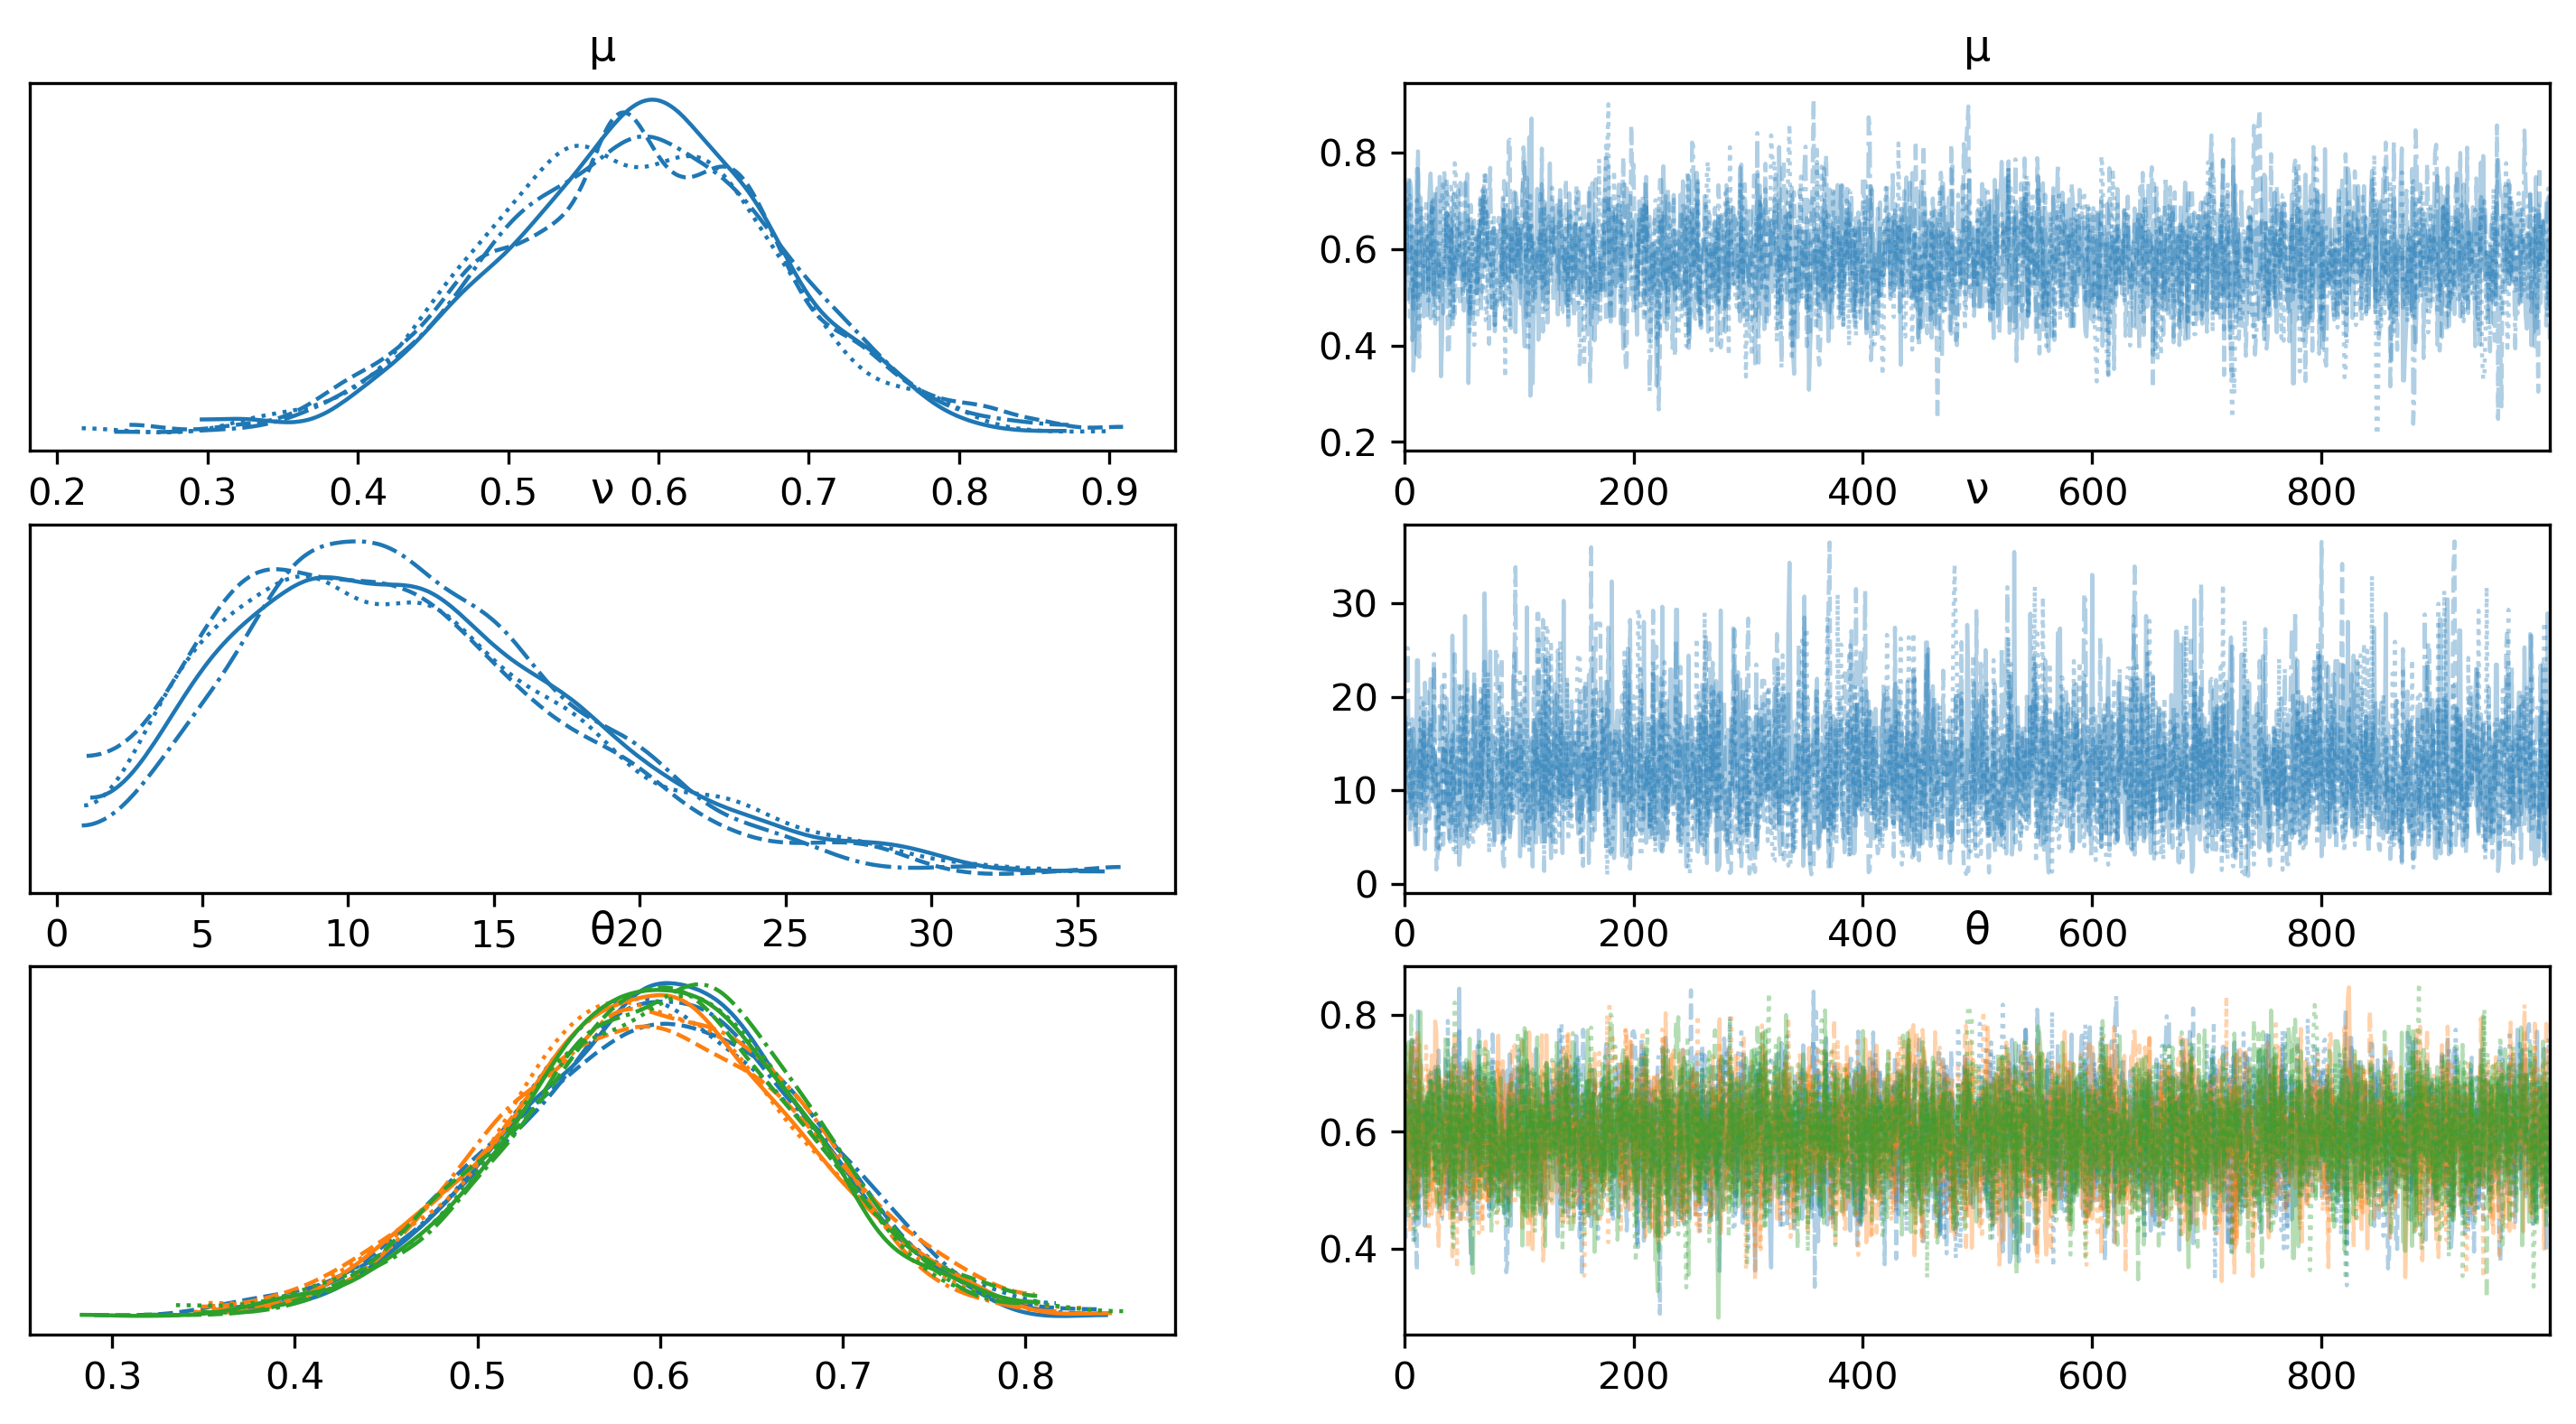

In [56]:
az.plot_trace(test1)

In [59]:
posterior = az.extract(test1, num_samples=100)




In [65]:
posterior[["μ", "ν"]].to_array().values.T

array([[ 0.65130933,  6.46493206],
       [ 0.75256224,  5.86070441],
       [ 0.41709615, 13.64083423],
       [ 0.62357106, 16.700351  ],
       [ 0.64821524, 20.53658247],
       [ 0.68046815,  6.5078962 ],
       [ 0.60904046,  5.08843187],
       [ 0.64775348, 15.58120832],
       [ 0.58734375, 11.91333144],
       [ 0.66899745,  3.69561621],
       [ 0.64455559, 17.75349503],
       [ 0.62930336,  8.80306498],
       [ 0.41407002, 15.41603297],
       [ 0.54741561,  7.4124726 ],
       [ 0.60106662, 11.99178232],
       [ 0.66429526, 17.91523421],
       [ 0.57283215, 13.79971266],
       [ 0.65301183,  8.7825186 ],
       [ 0.54031014, 10.30741555],
       [ 0.567903  , 15.80621076],
       [ 0.66777279, 13.15396603],
       [ 0.64455559, 17.75349503],
       [ 0.60631929, 27.09365044],
       [ 0.51684726, 36.60751857],
       [ 0.70751768,  8.6832784 ],
       [ 0.57453994, 12.4858033 ],
       [ 0.58291392,  7.94244225],
       [ 0.57327517,  7.06063891],
       [ 0.62803924,

In [70]:
posterior[["μ", "ν"]].to_array().values.T

array([[ 0.65130933,  6.46493206],
       [ 0.75256224,  5.86070441],
       [ 0.41709615, 13.64083423],
       [ 0.62357106, 16.700351  ],
       [ 0.64821524, 20.53658247],
       [ 0.68046815,  6.5078962 ],
       [ 0.60904046,  5.08843187],
       [ 0.64775348, 15.58120832],
       [ 0.58734375, 11.91333144],
       [ 0.66899745,  3.69561621],
       [ 0.64455559, 17.75349503],
       [ 0.62930336,  8.80306498],
       [ 0.41407002, 15.41603297],
       [ 0.54741561,  7.4124726 ],
       [ 0.60106662, 11.99178232],
       [ 0.66429526, 17.91523421],
       [ 0.57283215, 13.79971266],
       [ 0.65301183,  8.7825186 ],
       [ 0.54031014, 10.30741555],
       [ 0.567903  , 15.80621076],
       [ 0.66777279, 13.15396603],
       [ 0.64455559, 17.75349503],
       [ 0.60631929, 27.09365044],
       [ 0.51684726, 36.60751857],
       [ 0.70751768,  8.6832784 ],
       [ 0.57453994, 12.4858033 ],
       [ 0.58291392,  7.94244225],
       [ 0.57327517,  7.06063891],
       [ 0.62803924,

Text(0.5, 0, '$θ_{prior}$')

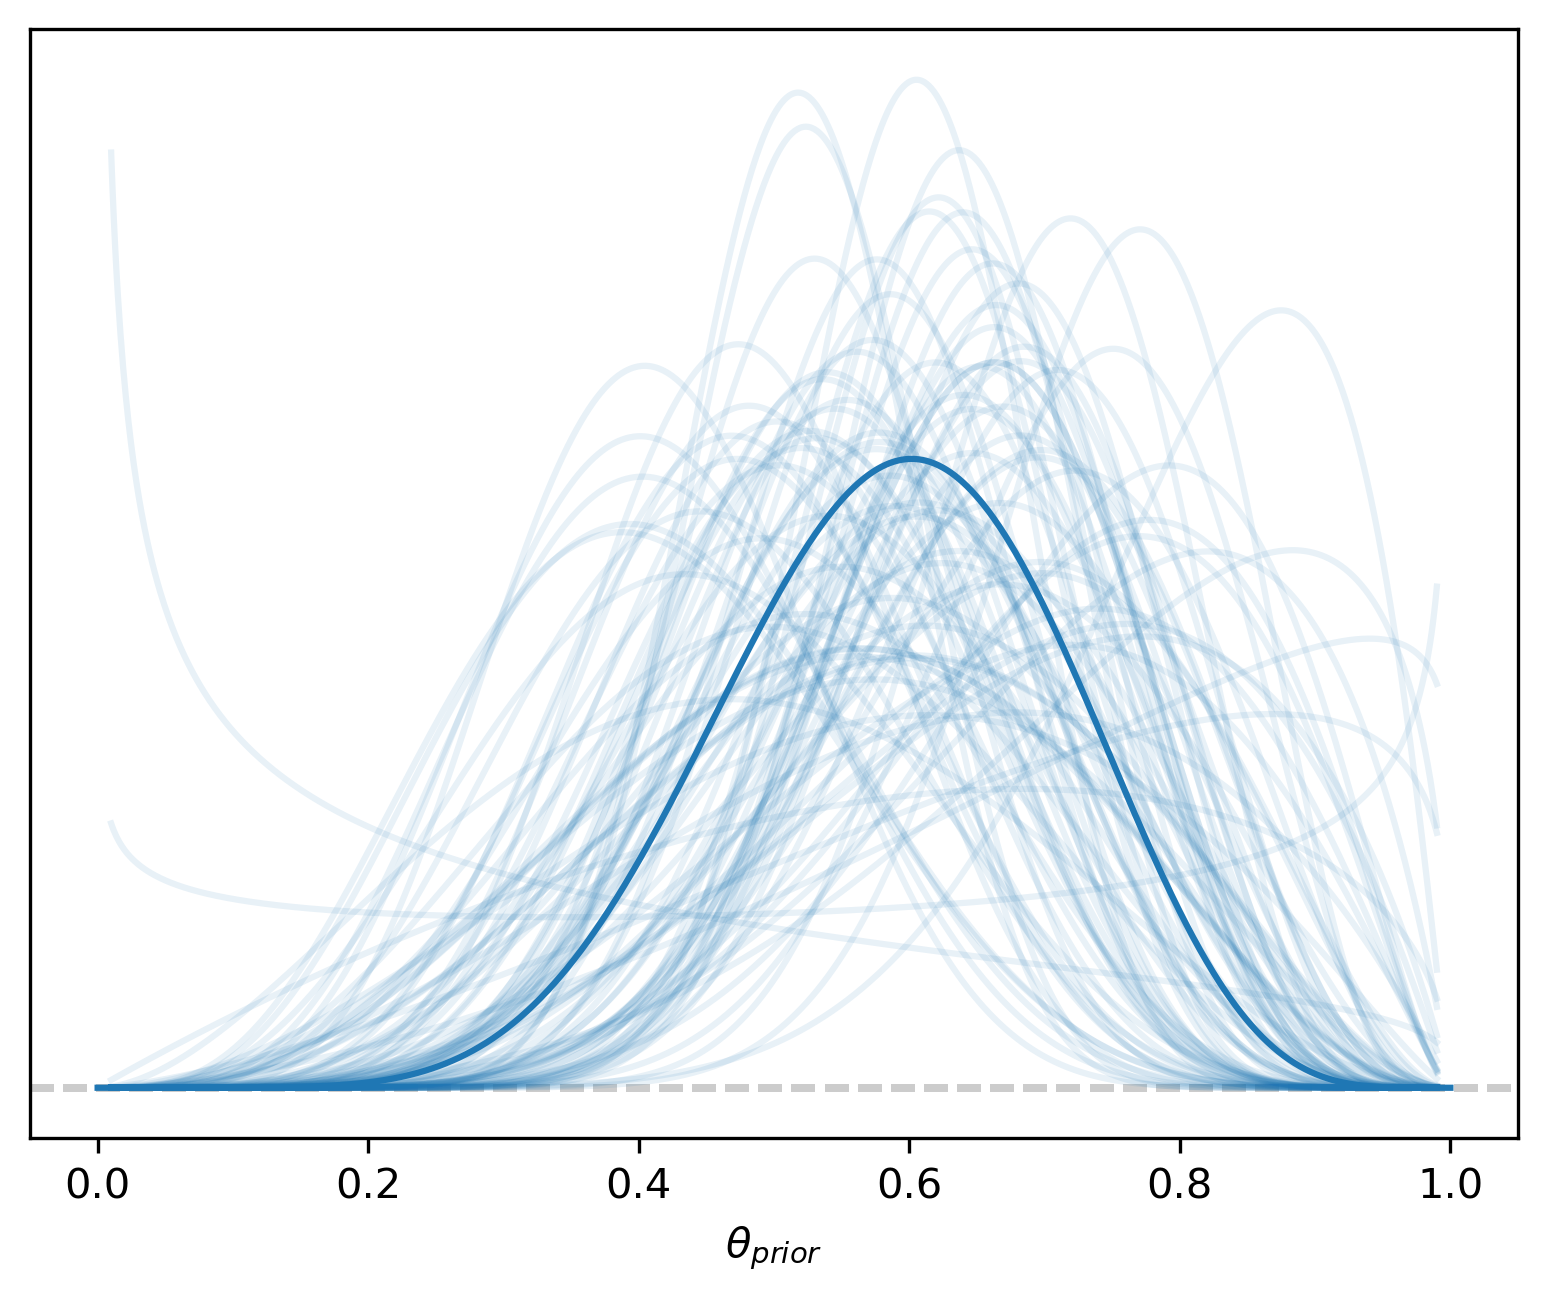

In [75]:
for sample in posterior[["μ", "ν"]].to_array().values.T:
    pz.Beta(mu=sample[0], kappa=sample[1]).plot_pdf(legend=None, 
                                                    color="C0", 
                                                    alpha=0.1, 
                                                    support=(0.01, 0.99), 
                                                    moments="m")
pz.Beta(mu=posterior["μ"].mean().item(), 
        kappa=posterior["ν"].mean().item()).plot_pdf(legend=None, 
                                                     color="C0", 
                                                     moments="m")
plt.xlabel('$θ_{prior}$')

In [78]:
football = pd.read_csv("data/football_players.csv", dtype={'position':'category'})
display(football)

,name,position,goals,shots
0,Aaron Connolly,FW,5,59
1,Aaron Cresswell,DF,4,69
2,Aaron Hunt,MF,3,30
3,Aaron Lennon,MF,1,5
4,Aaron Leya Iseka,FW,10,76
...,...,...,...,...
2677,Óscar Mingueza,DF,2,12
2678,Óscar Plano,MF,12,124
2679,Óscar Rodríguez,MF,13,133
2680,Óscar Trejo,MF,1,20


In [81]:
pos_idx = football.position.cat.codes.values
pos_idx

array([1, 0, 3, ..., 3, 3, 0], dtype=int8)

In [84]:
pos_codes = football.position.cat.categories
pos_codes

Index(['DF', 'FW', 'GK', 'MF'], dtype='object')

In [86]:
n_pos = pos_codes.size
n_pos

4

In [88]:
n_player = football.index.size
n_player

2682

In [ ]:
coords = {"pos": pos_codes}
with pm.Model(coords=coords) as model_football:
    
    # 사전 분포의 95% 확률 질량이 0에서 0.5 사이에 위치
    μ = pm.Beta('μ', 1.7, 5.8)
    ν = pm.Gamma('ν', mu=175, sigma=50)

    # Parameters for positions
    μ_p = pm.Beta('μ_p', mu=μ, nu=ν, dims='pos')

    # 확률 질량의 90%가 50에서 200 사이에 위치하도록 설정
    ν_p = pm.Gamma('ν_p', mu=125, sigma=50, dims='pos')

    θ = pm.Beta('θ', mu=μ_p[pos_idx], nu=ν_p[pos_idx])

    _ = pm.Binomial('gs', n=football.shots.values, p=θ, observed=football.goals.values)

    idata_football = pm.sample(draws=3000, target_accept=0.95, random_seed=4591)
    

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [μ, ν, μ_p, ν_p, θ]


Sampling 4 chains for 1_000 tune and 3_000 draw iterations (4_000 + 12_000 draws total) took 240 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


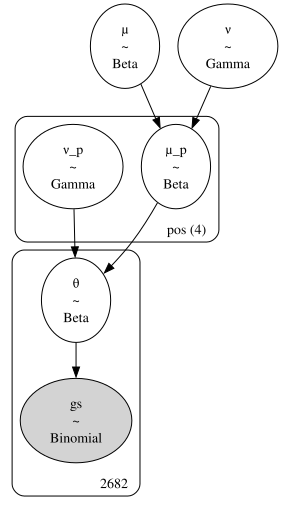

In [94]:
pm.model_to_graphviz(model_football)


In [108]:
idata_football

Inference data with groups:
	> posterior
	> sample_stats
	> observed_data

Text(0.5, 1.0, 'messi')

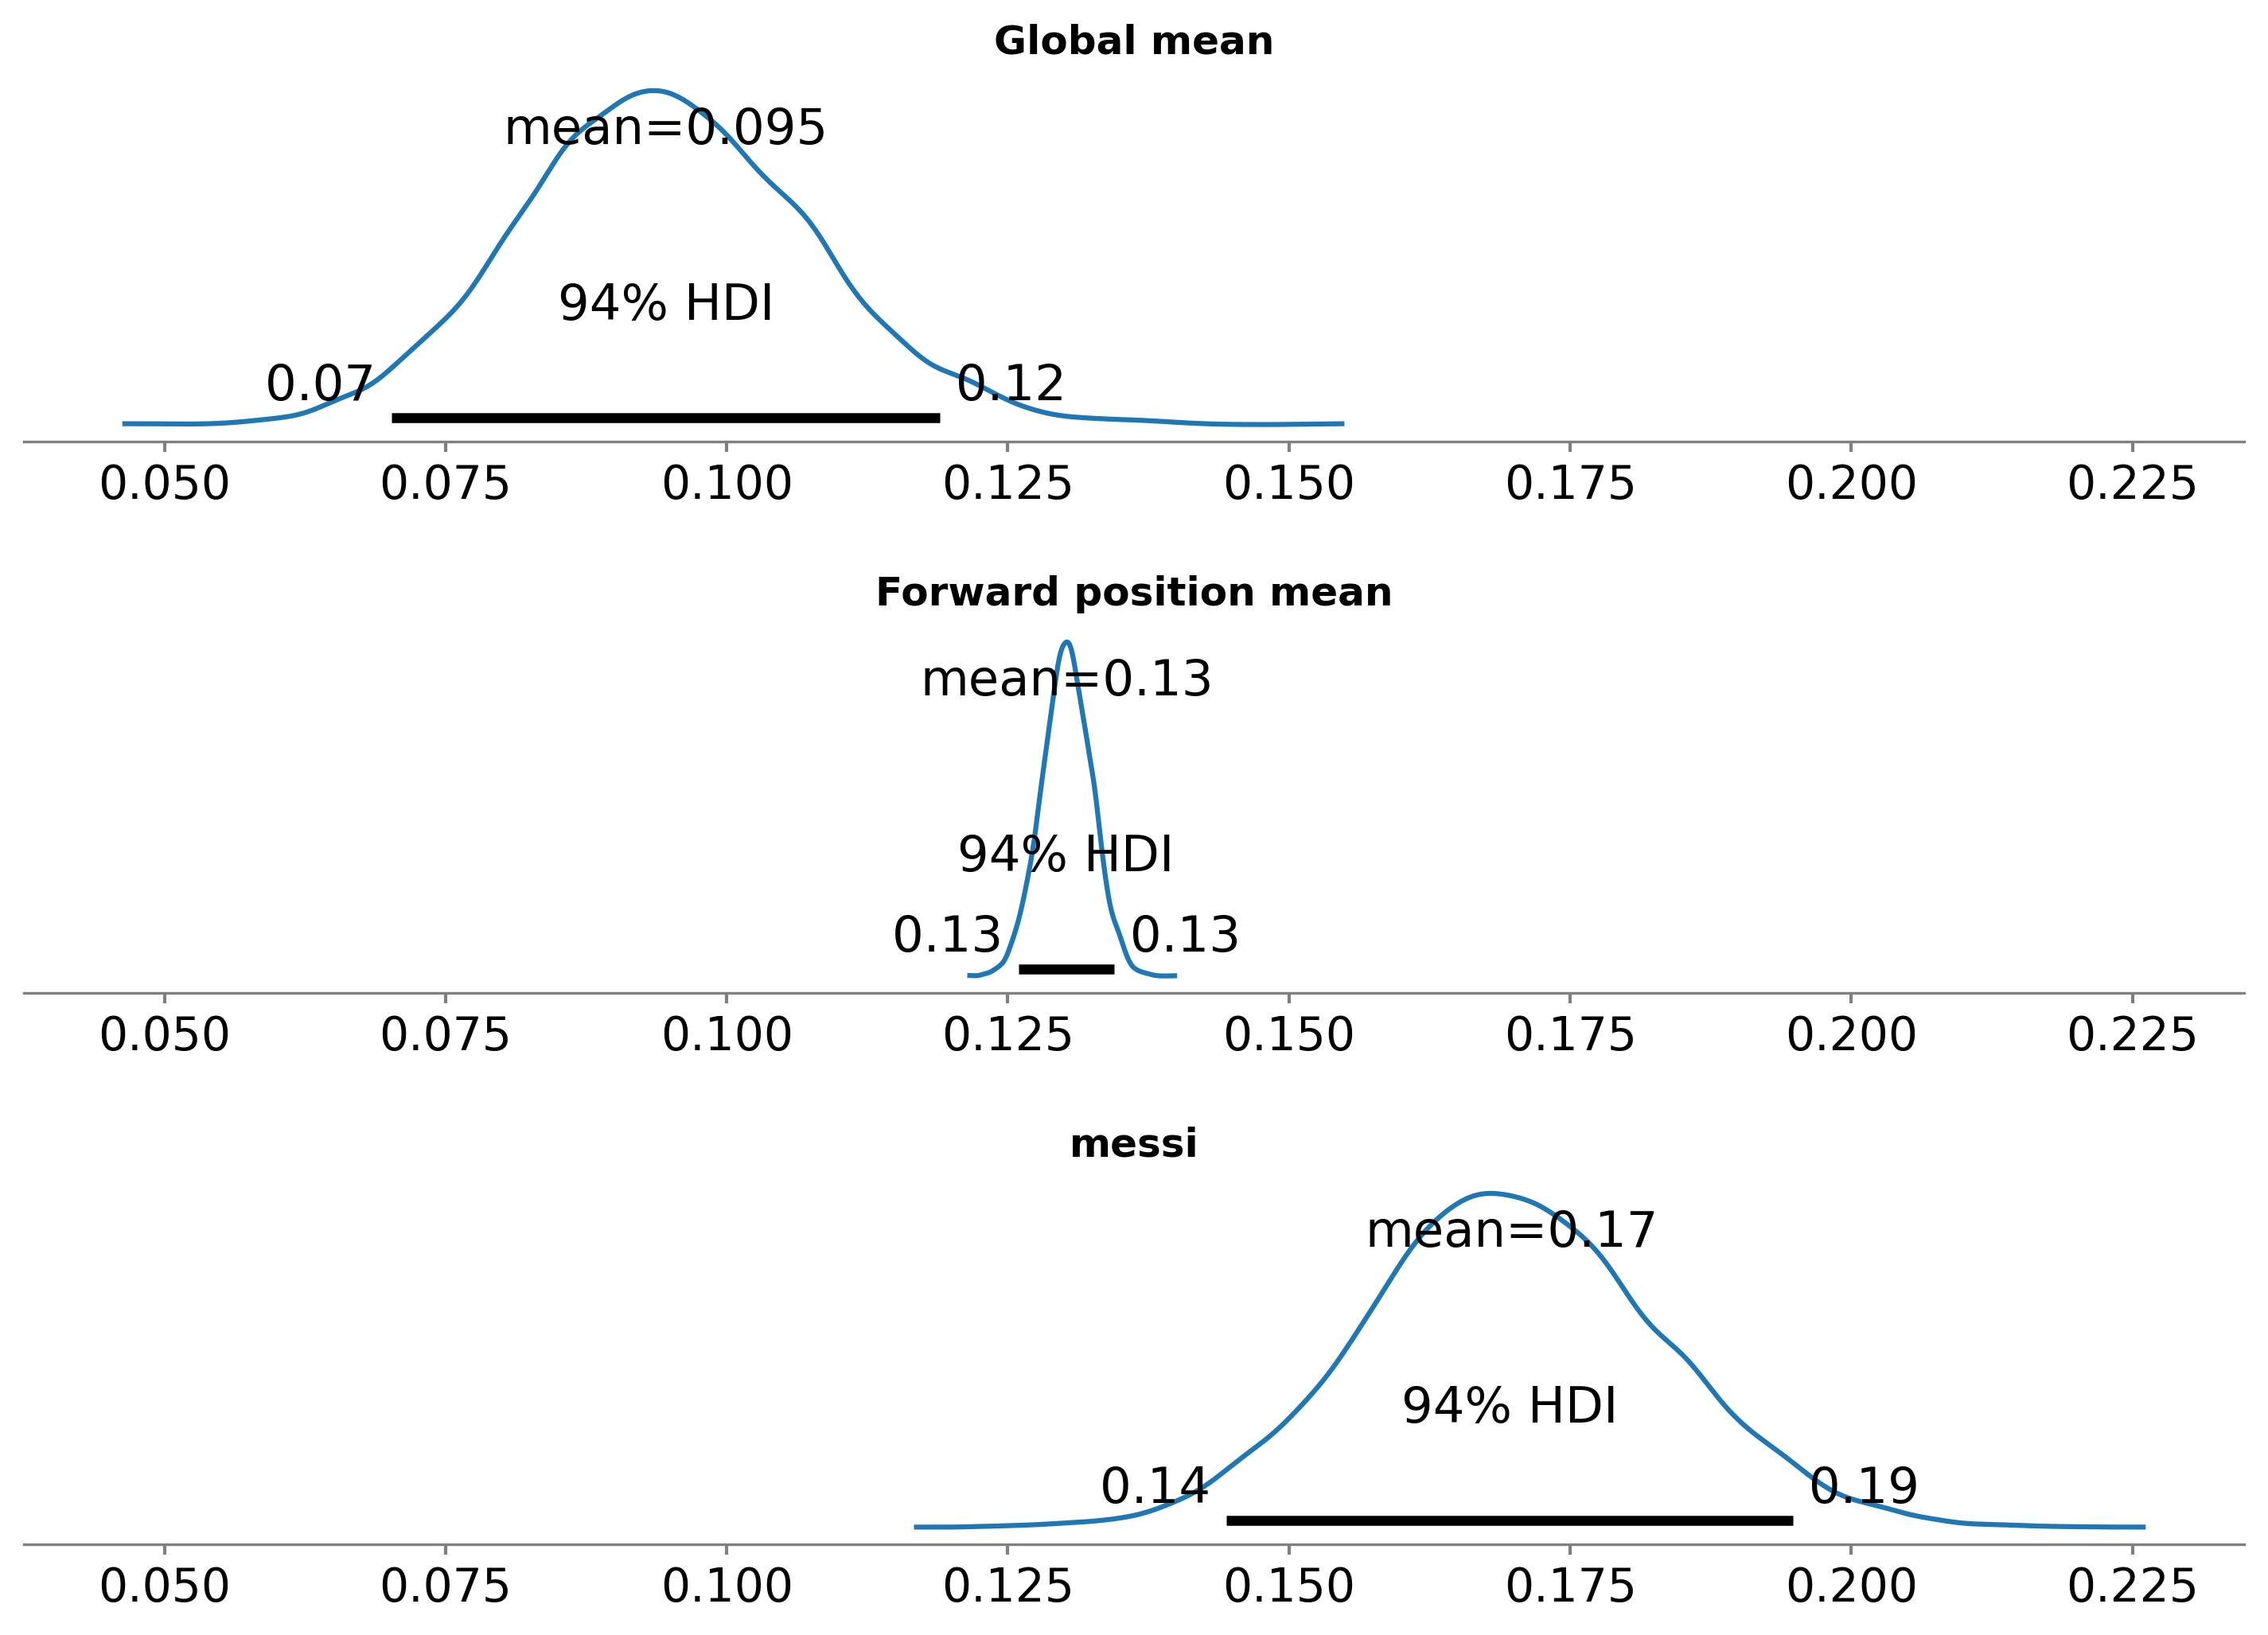

In [121]:
_, ax = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
plt.subplots_adjust(hspace=0.5)
az.plot_posterior(idata_football, var_names=['μ'], ax=ax[0])
ax[0].set_title(r"Global mean", fontdict={'weight': 'bold'})
az.plot_posterior(idata_football.posterior.sel(pos='FW'), var_names='μ_p', ax=ax[1])
ax[1].set_title(r"Forward position mean", fontdict={'weight': 'bold'})
az.plot_posterior(idata_football.posterior.sel(θ_dim_0=1457), var_names='θ', ax=ax[2])
ax[2].set_title(r"messi", fontdict={'weight': 'bold'})


<Axes: title={'center': 'μ_p'}>

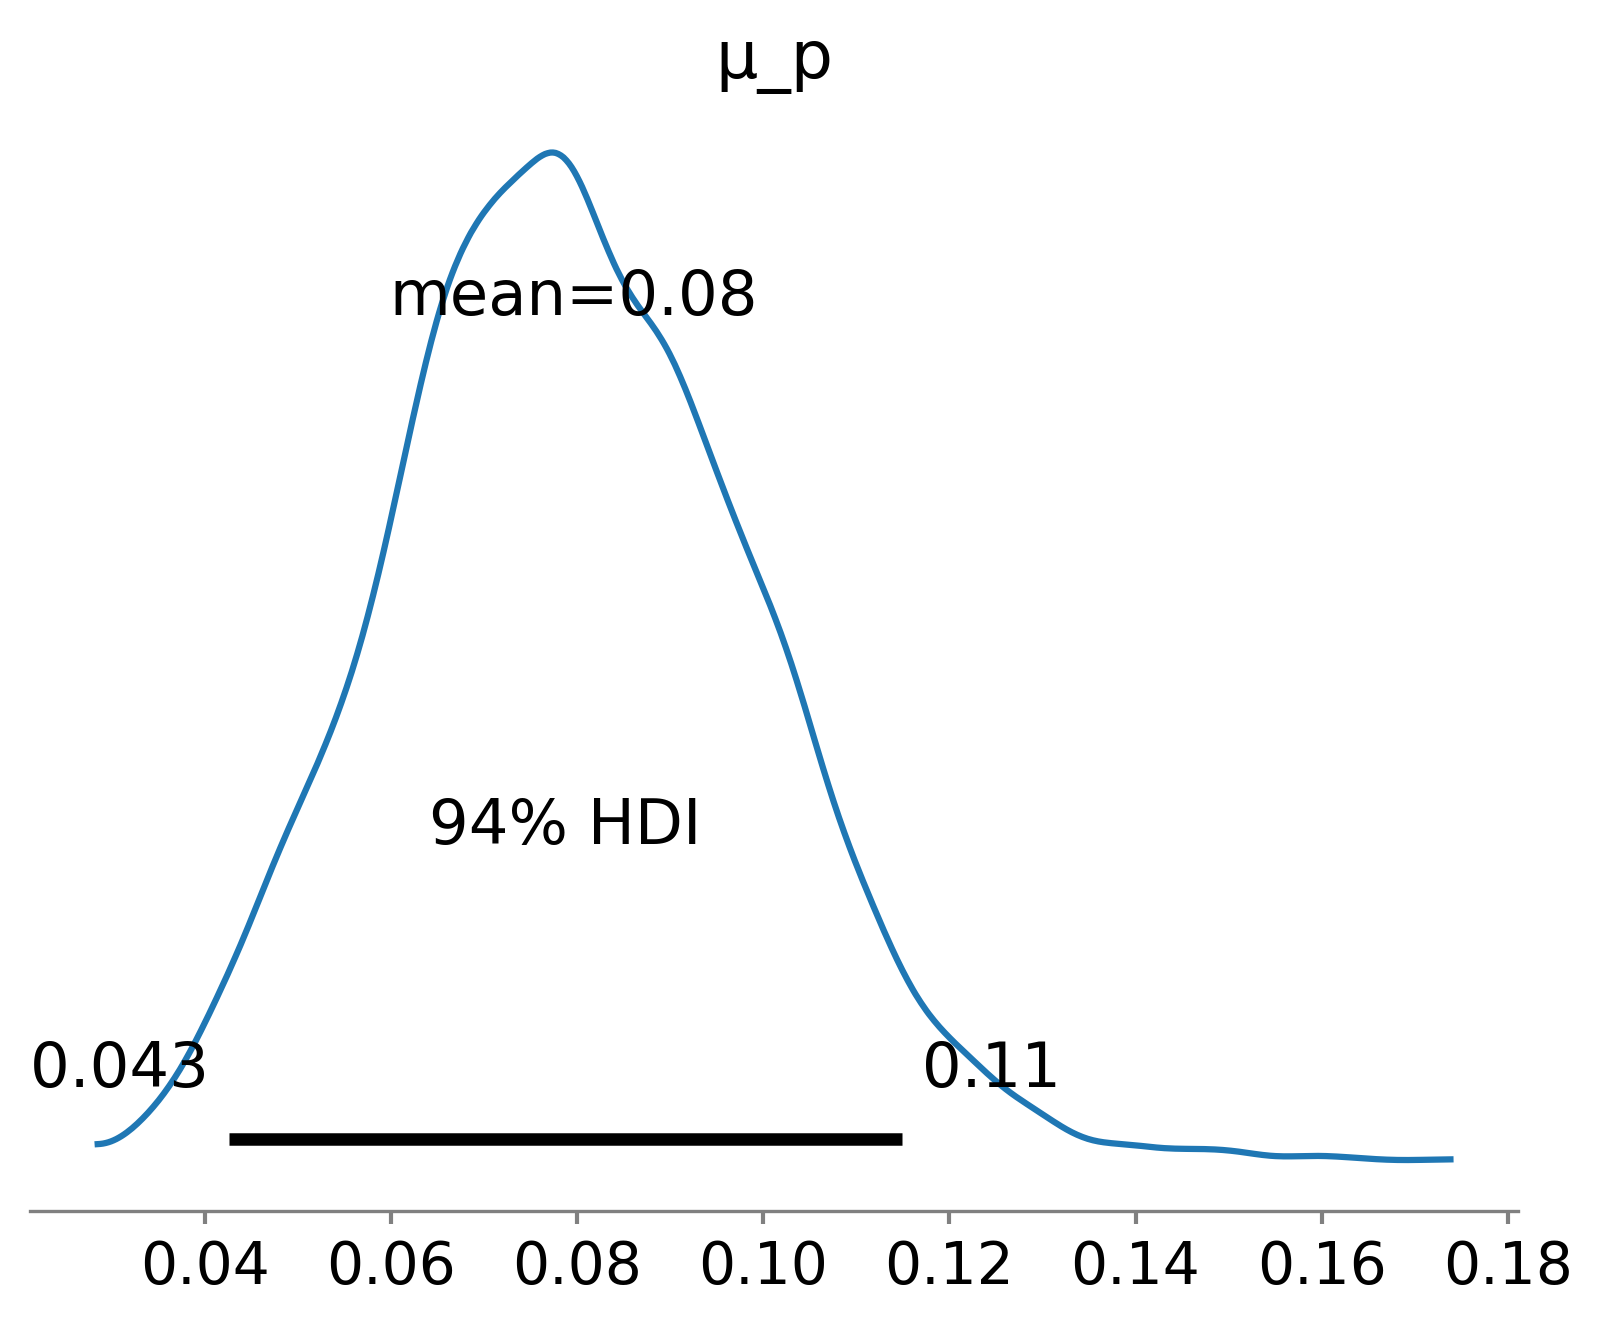

In [122]:
az.plot_posterior(idata_football.posterior.sel(pos='GK'), var_names='μ_p')

array([<Axes: title={'center': '94.0% HDI'}>], dtype=object)

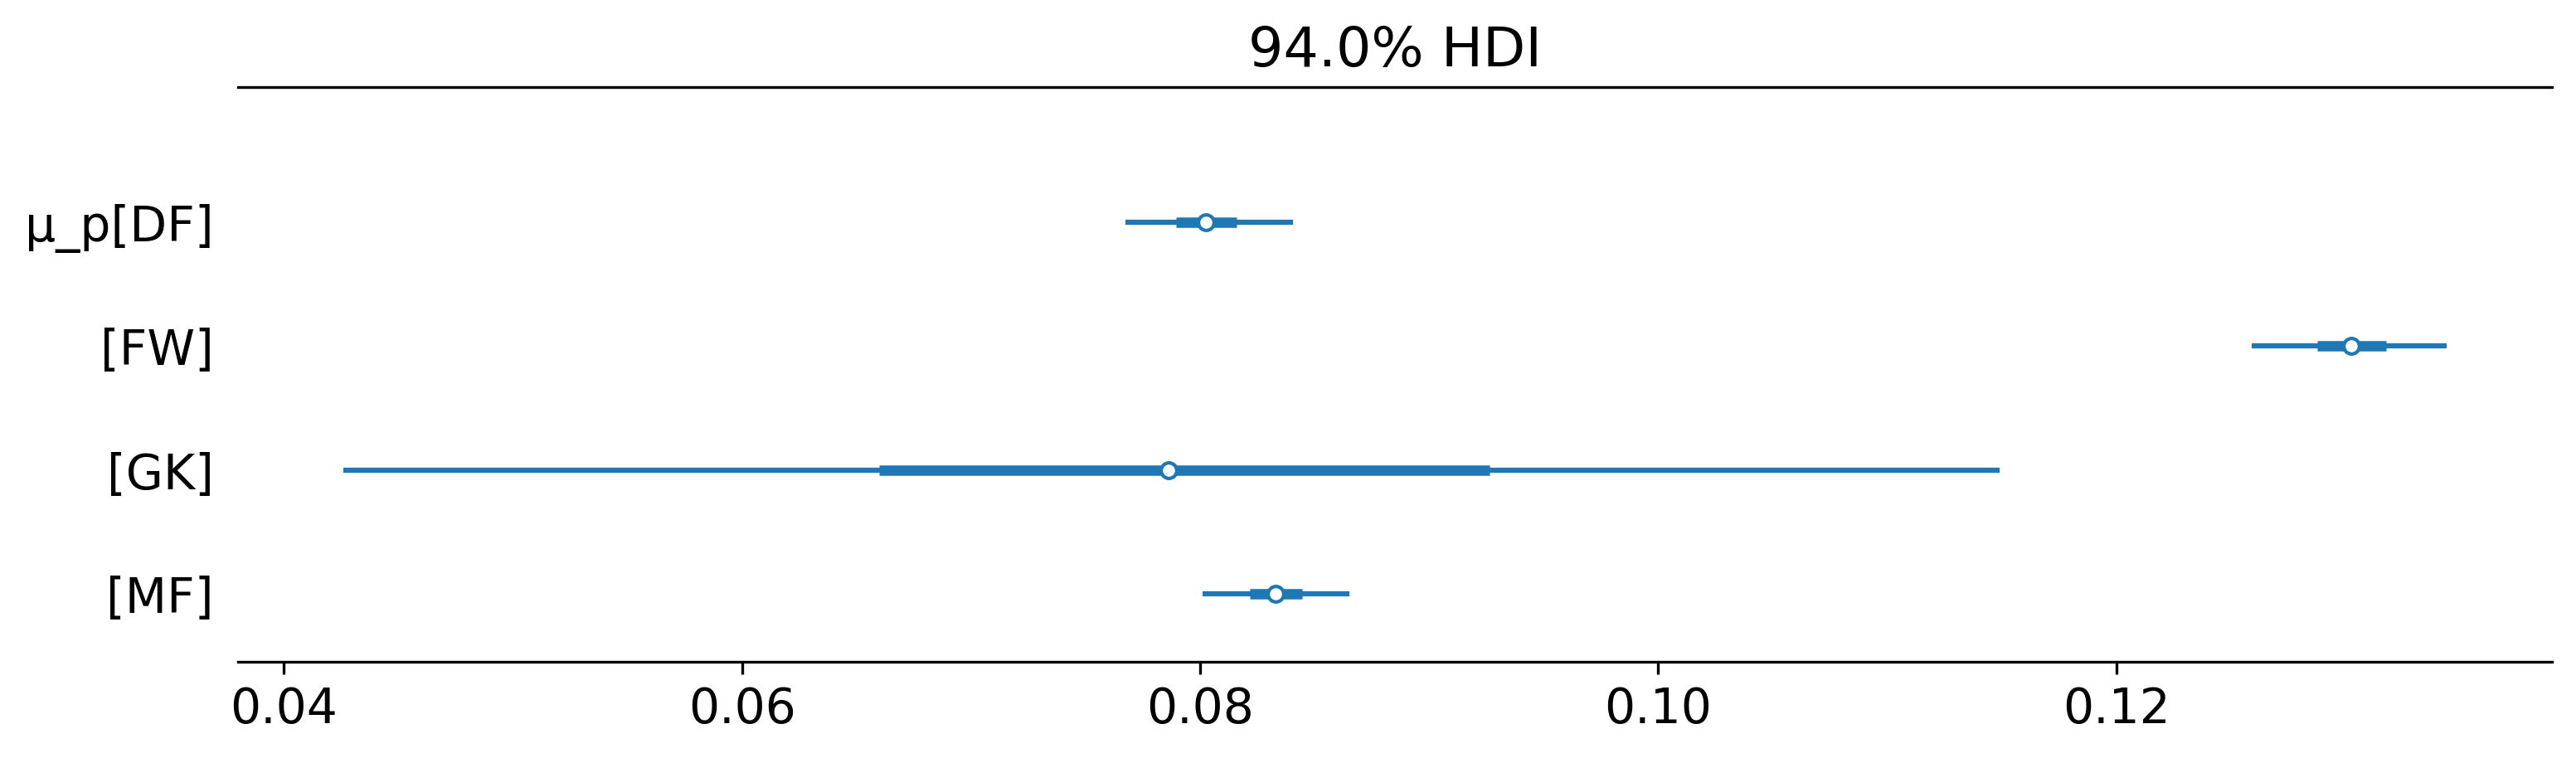

In [125]:
az.plot_forest(idata_football, var_names='μ_p', combined=True, figsize=(12, 3))

In [126]:
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import preliz as pz

In [135]:
N_samples = [30, 30, 30]
G_samples = [18, 3, 3]
group_idx = np.repeat(np.arange(len(N_samples)), N_samples)
data = []
for i in range(0, len(N_samples)):
    data.extend(np.repeat([1, 0], [G_samples[i], N_samples[i] - G_samples[i]]))

In [128]:
data

[1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0]

In [136]:
with pm.Model() as model_h:
    μ = pm.Beta('μ', 1., 1.)
    ν = pm.HalfNormal('ν', 10)
    θ = pm.Beta('θ', mu=μ, nu=ν, shape=len(N_samples))
    y = pm.Bernoulli('y', p=θ[group_idx], observed=data)

    idata_h = pm.sample(random_seed=4591)


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [μ, ν, θ]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 3 seconds.


In [137]:
with pm.Model() as model_nh:
    θ = pm.Beta('θ', 1, 1, shape=len(N_samples))
    y = pm.Bernoulli('y', p=θ[group_idx], observed=data)

    idata_nh = pm.sample(random_seed=4591)


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [θ]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 2 seconds.


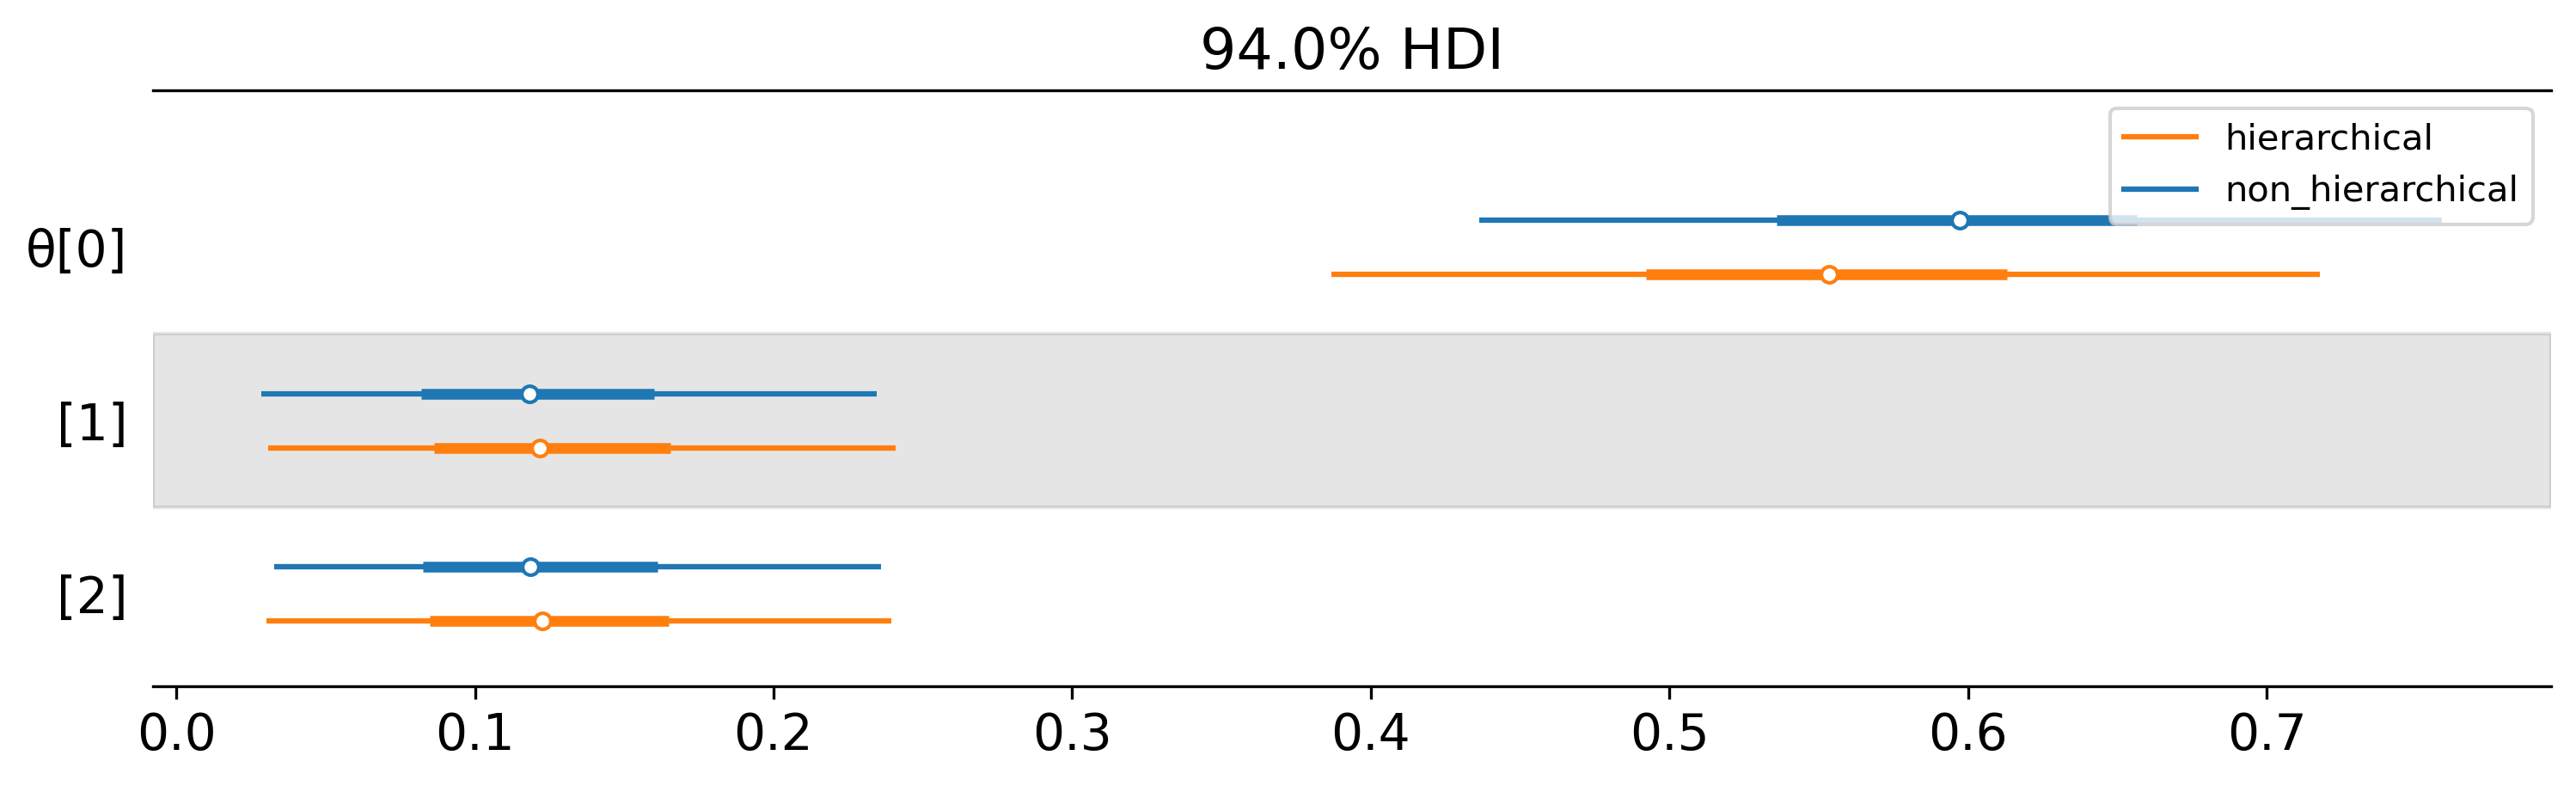

In [138]:
axes = az.plot_forest([idata_nh, idata_h], model_names=['non_hierarchical', 'hierarchical'],
                      var_names='θ', combined=True, r_hat=False, ess=False, figsize=(12, 3),
                      colors='cycle')
y_lims = axes[0].get_ylim()

In [140]:
tips = pd.read_csv("../code/data/tips.csv")
tips

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


In [141]:
categories = np.array(['Thur', 'Fri', 'Sat', 'Sun'])
tip = tips.tip.values
idx = pd.Categorical(tips.day, categories=categories).codes
idx

array([3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 3, 3, 3, 3, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 2, 2, 2, 2, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 0], dtype=int8)

In [142]:
coords = {'days': categories, 'days_flat': categories[idx]}
coords

{'days': array(['Thur', 'Fri', 'Sat', 'Sun'], dtype='<U4'),
 'days_flat': array(['Sun', 'Sun', 'Sun', 'Sun', 'Sun', 'Sun', 'Sun', 'Sun', 'Sun',
        'Sun', 'Sun', 'Sun', 'Sun', 'Sun', 'Sun', 'Sun', 'Sun', 'Sun',
        'Sun', 'Sat', 'Sat', 'Sat', 'Sat', 'Sat', 'Sat', 'Sat', 'Sat',
        'Sat', 'Sat', 'Sat', 'Sat', 'Sat', 'Sat', 'Sat', 'Sat', 'Sat',
        'Sat', 'Sat', 'Sat', 'Sat', 'Sat', 'Sun', 'Sun', 'Sun', 'Sun',
        'Sun', 'Sun', 'Sun', 'Sun', 'Sun', 'Sun', 'Sun', 'Sun', 'Sun',
        'Sun', 'Sun', 'Sat', 'Sat', 'Sat', 'Sat', 'Sat', 'Sat', 'Sat',
        'Sat', 'Sat', 'Sat', 'Sat', 'Sat', 'Sat', 'Sat', 'Sat', 'Sat',
        'Sat', 'Sat', 'Sat', 'Sat', 'Sat', 'Thur', 'Thur', 'Thur', 'Thur',
        'Thur', 'Thur', 'Thur', 'Thur', 'Thur', 'Thur', 'Thur', 'Thur',
        'Thur', 'Fri', 'Fri', 'Fri', 'Fri', 'Fri', 'Fri', 'Fri', 'Fri',
        'Fri', 'Fri', 'Fri', 'Fri', 'Sat', 'Sat', 'Sat', 'Sat', 'Sat',
        'Sat', 'Sat', 'Sat', 'Sat', 'Sat', 'Sun', 'Sun', 'Sun', 'Sun'

In [143]:
with pm.Model(coords=coords) as comparing_group_nh:
    mu = pm.HalfNormal("mu", sigma=5, dims='days')
    sigma = pm.HalfNormal("sigma", sigma=1, dims='days')

    Y = pm.Gamma("Y", mu=mu[idx], sigma=sigma[idx], observed=tip, dims='days_flat')
    idata_cg_nh = pm.sample(2000, random_seed=4591)

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu, sigma]


Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 5 seconds.


In [144]:
with pm.Model(coords=coords) as comparing_group_h_00:
    mu_g = pm.Gamma("mu_g", mu=5, sigma=2)
    mu = pm.HalfNormal("mu", sigma=mu_g, dims='days')
    sigma = pm.HalfNormal("sigma", sigma=1, dims='days')

    Y = pm.Gamma("Y", mu=mu[idx], sigma=sigma[idx], observed=tip, dims='days_flat')
    idata_cg_h_00 = pm.sample(random_seed=4591)

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu_g, mu, sigma]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 4 seconds.


In [145]:
with pm.Model(coords=coords) as comparing_group_h_01:
    mu_g = pm.Gamma("mu_g", mu=5, sigma=2)
    sigma_g = pm.Gamma("sigma_g", mu=2, sigma=1.5)
    mu = pm.Gamma("mu", mu=mu_g, sigma=sigma_g, dims='days')
    sigma = pm.HalfNormal("sigma", sigma=1, dims='days')

    Y = pm.Gamma("Y", mu=mu[idx], sigma=sigma[idx], observed=tip, dims='days_flat')
    idata_cg_h_01 = pm.sample(random_seed=4591)

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu_g, sigma_g, mu, sigma]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 9 seconds.
There were 96 divergences after tuning. Increase `target_accept` or reparameterize.


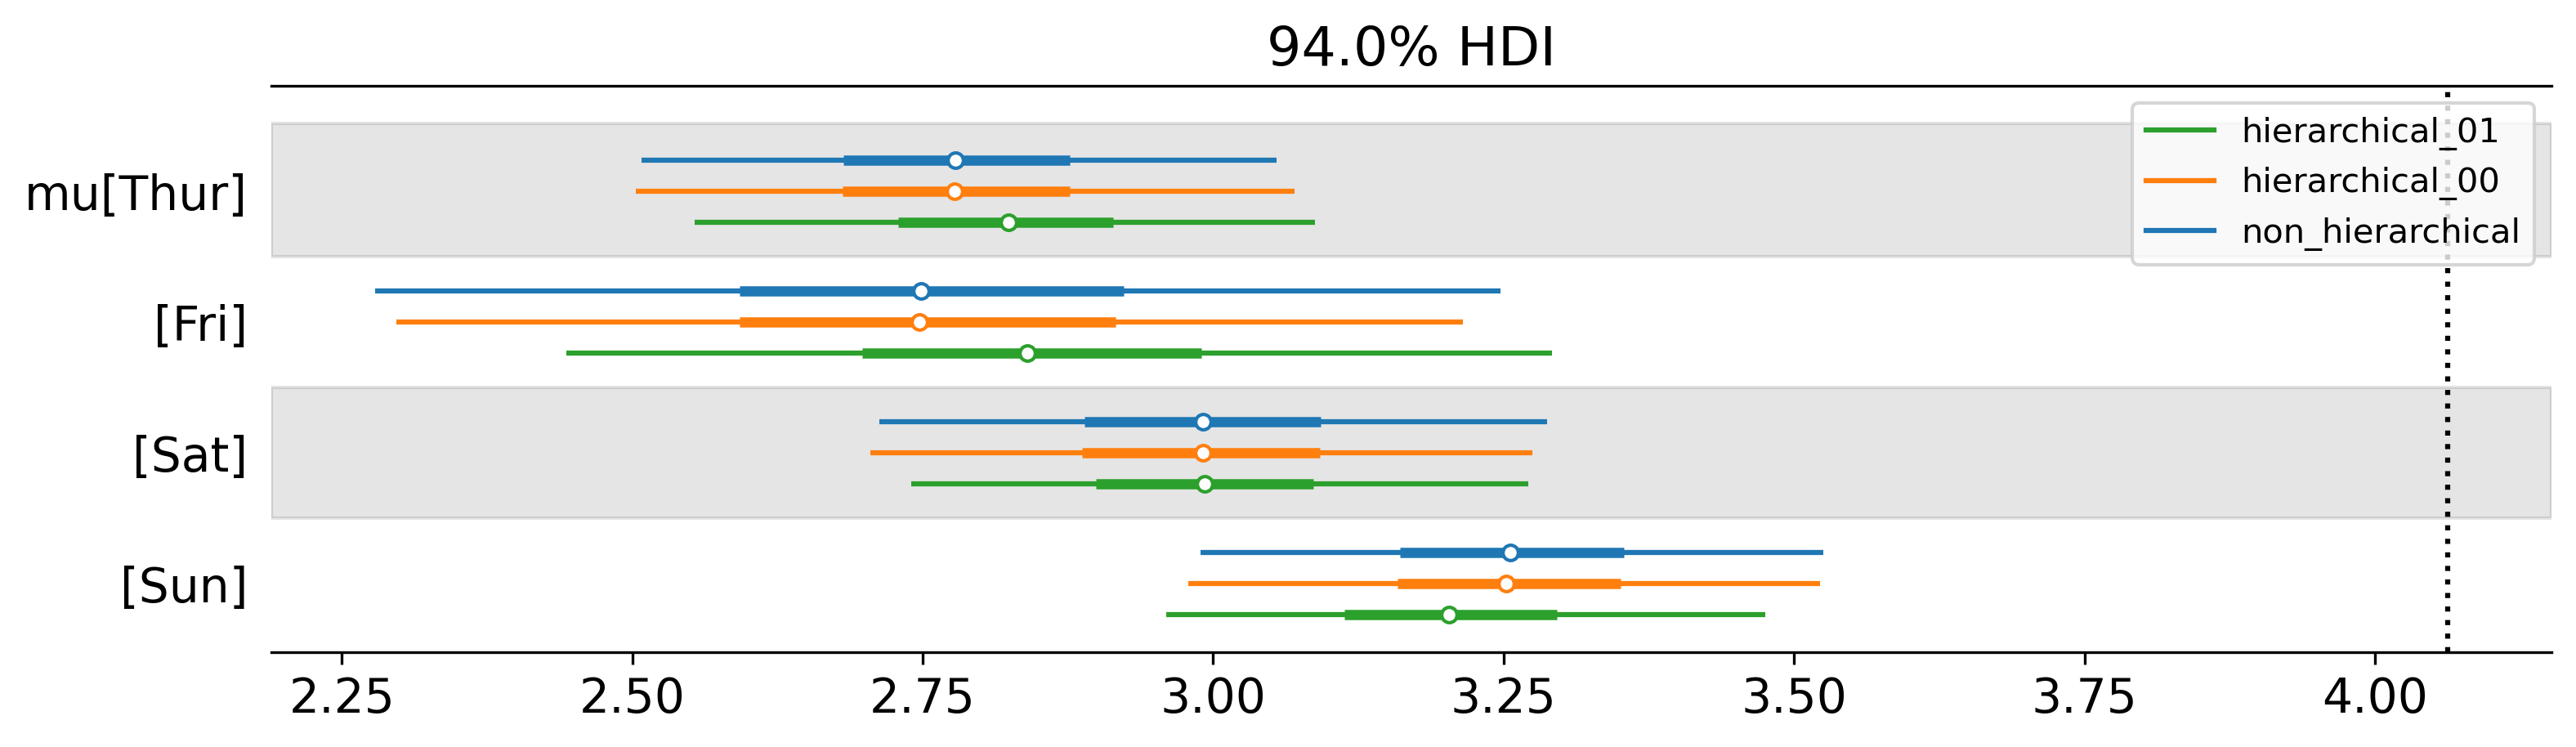

In [147]:
axes = az.plot_forest([idata_cg_nh, idata_cg_h_00, idata_cg_h_01],
                      model_names=['non_hierarchical', 'hierarchical_00', 'hierarchical_01'],
                      var_names='mu', combined=True, r_hat=False, ess=False, figsize=(12, 3),
                      colors='cycle')
y_lims = axes[0].get_ylim()
axes[0].vlines(idata_cg_h_00.posterior['mu_g'].mean(), *y_lims, color='k', ls=":")

In [148]:
football = pd.read_csv("../code/data/football_players.csv", dtype={'position': 'category'})
football['gps'] = football['goals'] / football["shots"]
football

,name,position,goals,shots,gps
0,Aaron Connolly,FW,5,59,0.084746
1,Aaron Cresswell,DF,4,69,0.057971
2,Aaron Hunt,MF,3,30,0.100000
3,Aaron Lennon,MF,1,5,0.200000
4,Aaron Leya Iseka,FW,10,76,0.131579
...,...,...,...,...,...
2677,Óscar Mingueza,DF,2,12,0.166667
2678,Óscar Plano,MF,12,124,0.096774
2679,Óscar Rodríguez,MF,13,133,0.097744
2680,Óscar Trejo,MF,1,20,0.050000


In [149]:
pos_idx = football.position.cat.codes.values
pos_idx

array([1, 0, 3, ..., 3, 3, 0], dtype=int8)

In [150]:
pos_codes = football.position.cat.categories
pos_codes

Index(['DF', 'FW', 'GK', 'MF'], dtype='object')

In [151]:
n_pos = pos_codes.size

In [152]:
n_players = football.index.size

In [156]:
coords = {'pos': pos_codes}
with pm.Model(coords=coords) as model_football:
    mu = pm.Beta("mu", 1.7, 5.8)
    nu = pm.Gamma("nu", mu=125, sigma=50)

    mu_p = pm.Beta("mu_p", mu=mu, nu=nu, dims='pos')
    nu_p = pm.Gamma("nu_p", mu=125, sigma=50, dims='pos')

    theta = pm.Beta("theta", mu=mu_p[pos_idx], nu=nu_p[pos_idx])
    _ = pm.Binomial("gs", n=football.shots.values, p=theta, observed=football.goals.values)

    idata_football = pm.sample(draws=3000, target_accept=0.95, random_seed=4591)

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu, nu, mu_p, nu_p, theta]


Sampling 4 chains for 1_000 tune and 3_000 draw iterations (4_000 + 12_000 draws total) took 268 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


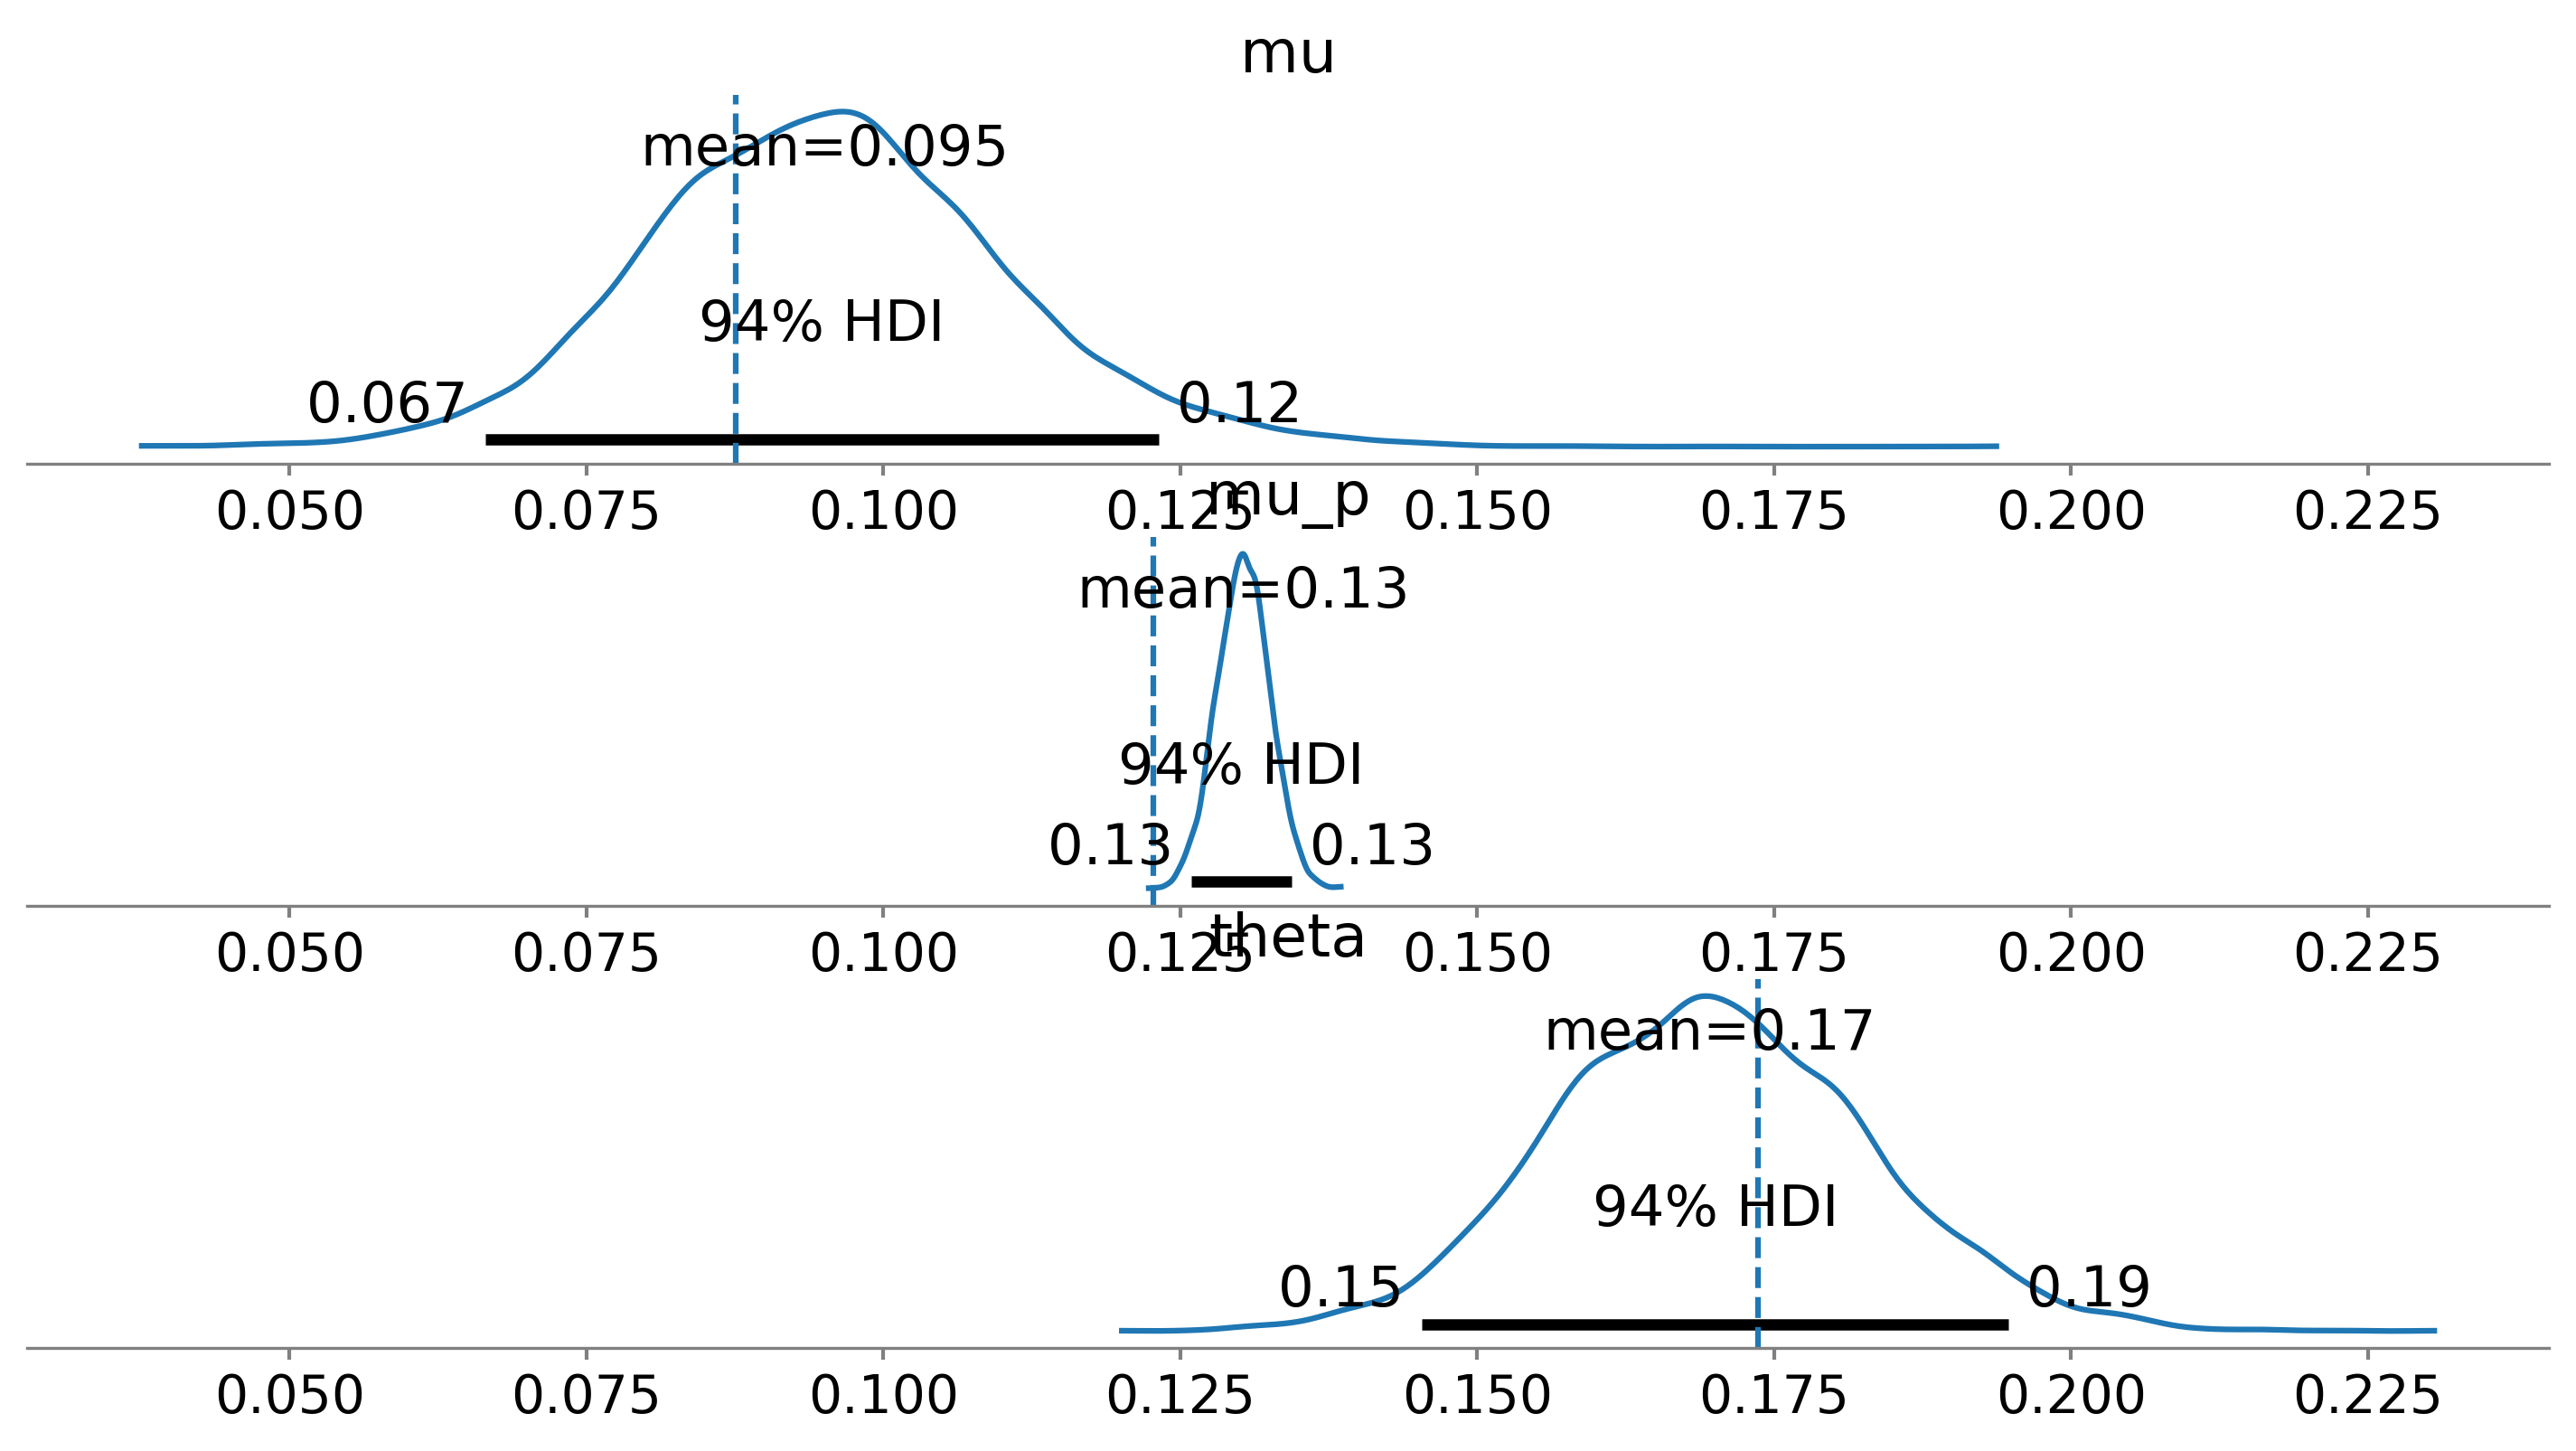

In [157]:
_, ax = plt.subplots(3, 1, figsize=(12, 6), sharex=True)
az.plot_posterior(idata_football, var_names='mu', ax=ax[0])
ax[0].axvline(football['gps'].mean(), ls="--")
az.plot_posterior(idata_football.posterior.sel(pos='FW'), var_names='mu_p', ax=ax[1])
ax[1].axvline(football['gps'][football['position']=='FW'].mean(), ls="--")
az.plot_posterior(idata_football.posterior.sel(theta_dim_0=1457), var_names='theta', ax=ax[2])
ax[2].axvline(football['gps'][football["name"] == "Lionel Messi"].item(), ls="--")